<a href="https://colab.research.google.com/github/kang25-gif/BA810/blob/main/%E2%80%9CHW2_ipynb%E2%80%9D%E7%9A%84%E5%89%AF%E6%9C%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HW2: Classifiers

In this homework fit and select a classifier to predict credit card default using `default_of_credit_card_clients` dataset from the course folder on Google drive. The data description is available at : https://www.kaggle.com/datasets/jishnukoliyadan/taiwan-default-credit-card-clients . If you find values in columns that are not explained in the description, you don't necessarily need to do anything about them for this homework.

1. Explore (5+5+10=20 points)
  1. load the dataset. Use only the columns "LIMIT_BAL", "SEX", "EDUCATION", "MARRIAGE", and "AGE" among predictors. The target is "default payment next month".
  1. identify the categorical features (with brief 1-3 sentence explanation), and
  1. produce the pairwise scatter plot only for the numeric variables.
1. Prepare a pipeline to (30 points)
  1. standardize the numeric attributes
  1. expand the categorical attributes to columns of 0/1 variables
  1. fit a `RandomForestClassifier` classifier
1. Search over the `max_depth` and `min_samples_leaf` parameters to find the best model per **balanced accuracy** metric. Use at least three different search strategies and discuss any differences you see in the results (≈ 150—200 words). (20 points)
1. Let's assume that the cost of missing a default (i.e., predicting non-default for a customer who ended up defaulting) is 10 times the cost of flagging a non-defaulter as defaulter. Let's further assume that the cost of correct predictions are 0. Use any one of the search strategies considered in the previous question to find the `RandomForestClassifier` that minimizes the cost. Discuss any differences between the results of the search using cost and not using cost in the previous step (≈ 150–200 words) (20 points)
1. Collaboration statement: Who did you discuss while answering this homework (whether to get or to provide help)? What questions/topics did you discuss? Did you use any generative AI tool, such as ChatGPT? If so, provide your prompts. (10 points)

Note: No penalty for either side. While getting help in figuring out how to solve is OK, all answers should be produced by you.

If you did not collaborate with anyone simply declare so.


## Submit
1. Submit your colab notebook as a pdf file. Use the code in [this notebook](https://colab.research.google.com/drive/1ZZLCXbvUS3DEpZt9fgVVhZxWMxNigu2a?usp=sharing) to convert your notebook to professional looking pdf. Do review the pdf file to make sure everything is appearing correctly before submitting!
1. Include a link to the colab notebook in your submission and make sure to provide us (TAs and professor) access to view it.


In [2]:
import pandas as pd
from google.colab import drive
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

drive.mount('/content/drive')
path = '/content/drive/MyDrive/BA810Material/Slides/Data/default_of_credit_card_clients.csv'
df = pd.read_csv(path)
df.head()


Mounted at /content/drive


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [3]:
filtered_df = df[["LIMIT_BAL", "SEX", "EDUCATION", "MARRIAGE", "AGE", "default payment next month"]]
filtered_df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,default payment next month
0,20000,2,2,1,24,1
1,120000,2,2,2,26,1
2,90000,2,2,2,34,0
3,50000,2,2,1,37,0
4,50000,1,2,1,57,0


Categorical Variable Explaination:

SEX,EDUCATION and MARRIAGE should consider as a categorical variables. SEX is simply divide to 1 = male and 2 = female. It has 4 options in Edcuation, 1 = graduate school, 2 = university, 3 = high school and 4 = others. In MARRIAGE, it only has 1 = married, 2 = single and 3 = others.

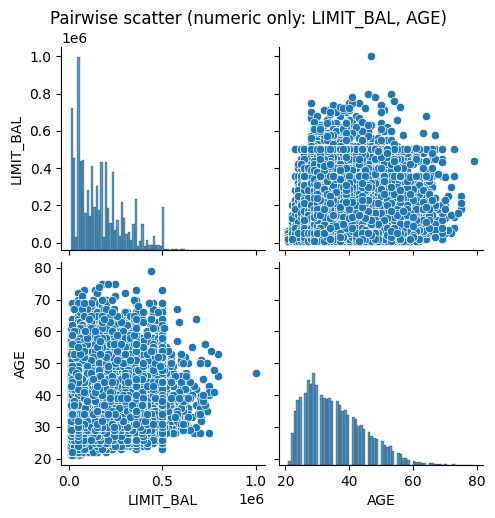

In [4]:
df_num = filtered_df[['LIMIT_BAL','AGE']]
sns.pairplot(df_num, diag_kind="hist", corner=False)
plt.suptitle("Pairwise scatter (numeric only: LIMIT_BAL, AGE)", y=1.02)
plt.show()

In [5]:
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from scipy.stats import randint
from sklearn.pipeline import Pipeline

numeric = ['LIMIT_BAL', 'AGE']
categorical = ['SEX', 'EDUCATION', 'MARRIAGE']

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
    ],
    remainder="drop",
)


rf = RandomForestClassifier(random_state=42, n_estimators=300, n_jobs=-1)

pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("rf", rf)
])

X = filtered_df.drop(columns=["default payment next month"])
y = filtered_df["default payment next month"].astype(int)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [6]:
pipe

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['LIMIT_BAL', 'AGE']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['SEX', 'EDUCATION',
                                                   'MARRIAGE'])])),
                ('rf',
                 RandomForestClassifier(n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [7]:
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import HalvingGridSearchCV
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, classification_report, make_scorer

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
bal_acc = "balanced_accuracy"

param_grid = {
    "rf__max_depth": [None, 6, 10, 14, 18, 25],
    "rf__min_samples_leaf": [1, 2, 4, 6, 10]
}

param_distributions = {
    "rf__max_depth": randint(4, 26),
    "rf__min_samples_leaf": randint(1, 11)
}

#1 Grid Search
grid = GridSearchCV(pipe, param_grid, scoring=bal_acc, cv=cv, n_jobs=-1) #n_jobs = -1, set all cup core to run
grid.fit(X_train, y_train)

#2 Randomized Search
rnd = RandomizedSearchCV(
    pipe, param_distributions, n_iter=25, scoring=bal_acc, cv=cv, n_jobs=-1,
    random_state=42
)
rnd.fit(X_train, y_train)

#3 Successive Halving
halving = HalvingGridSearchCV(
    pipe, param_grid, scoring=bal_acc, cv=cv, n_jobs=-1, random_state=42
)
halving.fit(X_train, y_train)

def summarize(name, search):
    print(f"\n=== {name} ===")
    print("Best params:", search.best_params_)
    print("Best CV balanced_accuracy:", round(search.best_score_, 4))

for name, search in [("GridSearchCV", grid), ("RandomizedSearchCV", rnd), ("HalvingGridSearchCV", halving)]:
    summarize(name, search)

# Pick the best of the three
searches = {"grid": grid, "random": rnd, "halving": halving}
best_name, best_search = max(searches.items(), key=lambda kv: kv[1].best_score_)
print(f"\nChosen best by CV: {best_name}")
best_model_bal = best_search.best_estimator_

y_pred_test = best_model_bal.predict(X_test)
print("\nTest balanced accuracy:", round(balanced_accuracy_score(y_test, y_pred_test), 4))
print("\nConfusion matrix (test):\n", confusion_matrix(y_test, y_pred_test))
print("\nClassification report (test):\n", classification_report(y_test, y_pred_test, digits=4))


=== GridSearchCV ===
Best params: {'rf__max_depth': 25, 'rf__min_samples_leaf': 1}
Best CV balanced_accuracy: 0.5229

=== RandomizedSearchCV ===
Best params: {'rf__max_depth': 24, 'rf__min_samples_leaf': 2}
Best CV balanced_accuracy: 0.5133

=== HalvingGridSearchCV ===
Best params: {'rf__max_depth': 18, 'rf__min_samples_leaf': 2}
Best CV balanced_accuracy: 0.5109

Chosen best by CV: grid

Test balanced accuracy: 0.5247

Confusion matrix (test):
 [[4207  466]
 [1129  198]]

Classification report (test):
               precision    recall  f1-score   support

           0     0.7884    0.9003    0.8406      4673
           1     0.2982    0.1492    0.1989      1327

    accuracy                         0.7342      6000
   macro avg     0.5433    0.5247    0.5198      6000
weighted avg     0.6800    0.7342    0.6987      6000



First, I selected the ranges for `max_depth` and `min_samples_leaf` as [6, 10, 14, 18, 25] and [1, 2, 4, 6, 10], respectively. For CV, I chose 5. Then, three search strategies—GridSearchCV, RandomizedSearchCV, and HalvingGridSearchCV—explored combinations of `max_depth` and `min_samples_leaf` hyperparameters for the random forest classifier using a balanced accuracy metric. GridSearchCV evaluated each pair of parameters in the grid and achieved the highest accuracy (≈ 0.523), ultimately selecting a deeper model (max_depth = 25, min_samples_leaf = 1). RandomizedSearchCV randomly sampled 25 parameter combinations from the specified range, generating a very similar model (max_depth = 24, min_samples_leaf = 2), but with slightly lower accuracy (≈ 0.513). HalvingGridSearchCV starts with many combinations and then gradually eliminates weaker combinations, eventually achieving similar performance (≈ 0.511).

All three methods found relatively close optimal depths (18-25) and minimum leaf node sizes (1-2) regions, but GridSearchCV's exhaustive nature resulted in a slightly higher score, at the cost of longer runtime. Random search and halving search offered faster, more resource-efficient alternatives with minimal accuracy loss. Overall, the results show that deeper decision trees capture more class differences, but the improvement in balancing accuracy is smaller, indicating that severe dataset imbalance limits performance improvements through tuning alone. The entire process took approximately 20 minutes to run. Reducing the number of parameters in the hyperparameter or the number of CVs might effectively reduce the time, but this would also decrease accuracy.

In [17]:
# Cost function
def total_cost(y_true, y_pred, fn_cost=10.0, fp_cost=1.0):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    return fn_cost * fn + fp_cost * fp

cost_scorer_total = make_scorer(total_cost, greater_is_better=False)

rnd_cost = RandomizedSearchCV(
    pipe, param_distributions, n_iter=25, scoring=cost_scorer_total, cv=cv,
    n_jobs=-1, random_state=42
)
rnd_cost.fit(X_train, y_train)

print("Best params (cost):", rnd_cost.best_params_)
print("Best CV total cost:", round(-rnd_cost.best_score_, 5))

best_model_cost = rnd_cost.best_estimator_
y_pred_cost = best_model_cost.predict(X_test)


print("Test balanced accuracy:", round(balanced_accuracy_score(y_test, y_pred_cost), 4))
print("\nConfusion matrix (cost-optimized model):\n", confusion_matrix(y_test, y_pred_cost))


Best params (cost): {'rf__max_depth': 24, 'rf__min_samples_leaf': 2}
Best CV total cost: 10055.8
Test balanced accuracy: 0.5117

Confusion matrix (cost-optimized model):
 [[4462  211]
 [1236   91]]


When tuning a random forest classifier using a cost-sensitive objective function, the model selection process prioritizes minimizing the total cost of misclassification rather than maximizing the balance accuracy. In this setting, the penalty for false negatives is ten times that of false positives, while the cost of correct predictions is zero. Using RandomizedSearchCV with a custom cost scorer, the optimal model has parameters of max_depth = 24 and min_samples_leaf = 2, with an average cross-validation cost of approximately 10,055.8 and a test confusion matrix of [[4462, 211], [1236, 91]].

Compared to the model optimized for balance accuracy, this cost-based model is more conservative in labeling defaulters—reducing false positives (211 vs. 466) but increasing false negatives (1236 vs. 1129). While the cost is low in the training model, this is not the case in the testing model. The total cost on the test set actually rises slightly to 12,571. This result indicates that simply adjusting hyperparameters cannot fully capture the asymmetric risk of credit defaults. For further improvement, we may need to adjust the classification probability threshold or apply class weights to make the model more inclined to identify genuine defaulters.

Collaboration statement:

I sought help from GPT during the process, mainly in model building. I asked GPT for advice on selecting the range of hyperparameters. When I finished the last part, I noticed that there was a difference between the optimal cost in CV and the actual cost, which made the results worse than the model generated based on accuracy. I asked GPT for insights on this, which gave me a deeper understanding.

